# 14 — Multi-session layer/Cre-line geometry statistics

This notebook reconstructs embedding geometry across all available sessions, merges session metadata, runs bootstrapped uncertainty summaries, and gates layer/Cre-line claims.

## Setup and asset index

In [1]:

from pathlib import Path
import os
import sys
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Edit this path only if your project has moved.
PROJECT_ROOT = Path(
    os.environ.get(
        "LATENT_MANIFOLD_PROJECT_ROOT",
        r"C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies",
    )
).resolve()

SRC_DIR = PROJECT_ROOT / "src"
if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f"PROJECT_ROOT does not exist: {PROJECT_ROOT}")
if not SRC_DIR.exists():
    raise FileNotFoundError(f"src directory does not exist: {SRC_DIR}")
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
os.chdir(PROJECT_ROOT)

cfg_path = PROJECT_ROOT / "configs" / "publication_upgrade.yaml"
if not cfg_path.exists():
    raise FileNotFoundError(f"Could not find publication config: {cfg_path}")
with cfg_path.open("r", encoding="utf-8") as f:
    pub_cfg = yaml.safe_load(f)
cfg = pub_cfg

# Versioned namespace. This prevents accidental overwriting of older publication outputs.
PUBLICATION_RUN_LABEL = os.environ.get("PUBLICATION_RUN_LABEL", "publication_upgrade_v3_multisession")
ALLOW_CANONICAL_PUBLICATION_WRITE = os.environ.get("ALLOW_CANONICAL_PUBLICATION_WRITE", "0") == "1"
if PUBLICATION_RUN_LABEL == "publication_upgrade" and not ALLOW_CANONICAL_PUBLICATION_WRITE:
    raise RuntimeError(
        "Refusing to write into the canonical publication_upgrade namespace. "
        "Use a versioned PUBLICATION_RUN_LABEL or set ALLOW_CANONICAL_PUBLICATION_WRITE=1 intentionally."
    )

class ProjectPaths:
    def __init__(self, root: Path, run_label: str):
        self.root = root
        self.configs_dir = root / "configs"
        self.data_dir = root / "data"
        self.external_dir = root / "data" / "external"
        self.raw_dir = root / "data" / "raw"
        self.interim_dir = root / "data" / "interim"
        self.processed_dir = root / "data" / "processed"
        self.versioned_processed_dir = self.processed_dir / run_label
        self.reports_dir = root / "reports"
        self.tables_dir = root / "reports" / "tables"
        self.figures_dir = root / "reports" / "figures"
        self.html_dir = root / "reports" / "html"
        self.publication_tables_dir = root / "reports" / "tables" / run_label
        self.publication_figures_dir = root / "reports" / "figures" / run_label
        self.manuscript_dir = root / "manuscript" / "top_journal_scaffold"
        for d in [
            self.versioned_processed_dir,
            self.publication_tables_dir,
            self.publication_figures_dir,
            self.manuscript_dir,
        ]:
            d.mkdir(parents=True, exist_ok=True)

paths = ProjectPaths(PROJECT_ROOT, PUBLICATION_RUN_LABEL)

def save_table(df, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    return path

def save_figure(fig, path, dpi=300):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    return path

# Upgrade helper functions shipped with this patch.
from v1_manifold_publication.multisession_core import (
    build_multisession_asset_index,
    candidate_feature_files,
    choose_best_feature_table,
    ready_sessions,
    movie_feature_targets,
    empirical_null_summary,
    safe_read_csv,
    safe_table_index,
    claim_gate_from_assets,
    ensure_table,
)

metadata_path = paths.external_dir / "allen_v1_natural_movie_experiments.csv"
asset_index = build_multisession_asset_index(paths, metadata_path=metadata_path)
save_table(asset_index, paths.publication_tables_dir / "00_multisession_asset_index.csv")

print("Using PROJECT_ROOT:", PROJECT_ROOT)
print("Publication run label:", PUBLICATION_RUN_LABEL)
print("Publication tables:", paths.publication_tables_dir)
print("Publication figures:", paths.publication_figures_dir)
print("Versioned processed dir:", paths.versioned_processed_dir)
display(asset_index)


Using PROJECT_ROOT: C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies
Publication run label: publication_upgrade_v3_multisession
Publication tables: C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies\reports\tables\publication_upgrade_v3_multisession
Publication figures: C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies\reports\figures\publication_upgrade_v3_multisession
Versioned processed dir: C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies\data\processed\publication_upgrade_v3_multisession


,session_id,feature_file,feature_shape,tensor_file,embedding_file,embedding_names,embedding_shapes,has_features,has_tensor,has_embeddings,ready_for_latent_decoding,ready_for_population_encoding,ready_for_full_neural_analysis
0,500855614,C:\Users\Peter\Documents\projects\NeuroAI\late...,"(900, 105)",C:\Users\Peter\Documents\projects\NeuroAI\late...,C:\Users\Peter\Documents\projects\NeuroAI\late...,"pca,pca_full,umap,isomap,cebra","pca:(900, 3);pca_full:(900, 20);umap:(900, 3);...",True,True,True,True,True,True
1,500964514,C:\Users\Peter\Documents\projects\NeuroAI\late...,"(900, 105)",C:\Users\Peter\Documents\projects\NeuroAI\late...,C:\Users\Peter\Documents\projects\NeuroAI\late...,"pca,pca_full,umap,isomap","pca:(900, 3);pca_full:(900, 20);umap:(900, 3);...",True,True,True,True,True,True
2,501271265,C:\Users\Peter\Documents\projects\NeuroAI\late...,"(900, 105)",C:\Users\Peter\Documents\projects\NeuroAI\late...,C:\Users\Peter\Documents\projects\NeuroAI\late...,"pca,pca_full,umap,isomap","pca:(900, 3);pca_full:(900, 20);umap:(900, 3);...",True,True,True,True,True,True


## Reconstruct geometry summaries from all saved embeddings

In [2]:
# ---------------------------------------------------------------------
# Notebook 14: reconstruct geometry time series for common embeddings
# ---------------------------------------------------------------------

from v1_manifold_publication.geometry_publication import (
    geometry_timeseries,
    summarize_geometry_ts,
)

common_embeddings = ["pca", "pca_full", "umap", "isomap"]

rows = []
ts_status = []

ready = (
    asset_index
    .loc[asset_index["has_embeddings"], "session_id"]
    .astype(str)
    .tolist()
)

print("Sessions with embeddings:", ready)
print("Common embeddings used for multi-session geometry:", common_embeddings)

for session_id in ready:
    emb_path = Path(
        asset_index.loc[
            asset_index["session_id"].astype(str) == str(session_id),
            "embedding_file",
        ].iloc[0]
    )

    print("\n" + "=" * 90)
    print("Session:", session_id)
    print("Embedding file:", emb_path)

    try:
        with np.load(emb_path, allow_pickle=False) as emb:
            available = [
                name for name in common_embeddings
                if name in emb.files
            ]

            print("Available common embeddings:", available)

            for name in available:
                Z = emb[name]

                if Z.ndim != 2 or Z.shape[0] <= 10 or Z.shape[1] < 2:
                    ts_status.append({
                        "session_id": session_id,
                        "embedding": name,
                        "status": "skipped",
                        "reason": f"Invalid embedding shape: {Z.shape}",
                    })
                    continue

                geom_ts = geometry_timeseries(Z)
                geom_ts = geom_ts.copy()
                geom_ts["session_id"] = session_id
                geom_ts["embedding"] = name

                save_table(
                    geom_ts,
                    paths.publication_tables_dir
                    / f"14_geometry_timeseries_session_{session_id}_{name}.csv",
                )

                summary = summarize_geometry_ts(geom_ts)

                pivot = (
                    summary
                    .set_index("metric")[["median", "p99", "max"]]
                    .stack()
                    .to_dict()
                )

                rows.append({
                    "session_id": session_id,
                    "embedding": name,
                    "n_frames": int(Z.shape[0]),
                    "embedding_dim": int(Z.shape[1]),
                    **{f"{k[0]}_{k[1]}": v for k, v in pivot.items()},
                })

                ts_status.append({
                    "session_id": session_id,
                    "embedding": name,
                    "status": "completed",
                    "n_frames": int(Z.shape[0]),
                    "embedding_dim": int(Z.shape[1]),
                })

    except Exception as exc:
        ts_status.append({
            "session_id": session_id,
            "embedding": None,
            "status": "failed",
            "reason": repr(exc),
        })

geom = pd.DataFrame(rows)
geometry_status = pd.DataFrame(ts_status)

save_table(
    geom,
    paths.publication_tables_dir / "publication_reconstructed_embedding_geometry.csv",
)

save_table(
    geom,
    paths.publication_tables_dir / "14_geometry_with_session_metadata.csv",
)

save_table(
    geometry_status,
    paths.publication_tables_dir / "14_geometry_reconstruction_status.csv",
)

display(geom.head(20))
display(geometry_status)

Sessions with embeddings: ['500855614', '500964514', '501271265']
Common embeddings used for multi-session geometry: ['pca', 'pca_full', 'umap', 'isomap']

Session: 500855614
Embedding file: C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies\data\processed\session_500855614_embeddings.npz
Available common embeddings: ['pca', 'pca_full', 'umap', 'isomap']

Session: 500964514
Embedding file: C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies\data\processed\session_500964514_embeddings.npz
Available common embeddings: ['pca', 'pca_full', 'umap', 'isomap']

Session: 501271265
Embedding file: C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies\data\processed\session_501271265_embeddings.npz
Available common embeddings: ['pca', 'pca_full', 'umap', 'isomap']


,session_id,embedding,n_frames,embedding_dim,speed_median,speed_p99,speed_max,curvature_median,curvature_p99,curvature_max,tangling_median,tangling_p99,tangling_max
0,500855614,pca,900,3,1.005158,2.503851,4.239799,1.107981,33.166636,191.321576,7.209709,138.906255,337.053336
1,500855614,pca_full,900,20,2.677863,4.246316,5.324176,0.480364,1.543484,2.586151,1.014677,2.951445,3.480076
2,500855614,umap,900,3,0.082220,0.752321,15.982136,8.756395,1795.714967,13350.645629,18.309289,5063.730136,26984.780552
3,500855614,isomap,900,3,1.200051,5.479009,8.527684,0.533106,136.010347,5195.263502,7.655994,2806.208298,64591.071953
4,500964514,pca,900,3,1.121127,3.401901,6.496040,0.999325,26.892121,72.917495,8.710293,199.840421,446.755228
5,500964514,pca_full,900,20,3.003222,4.910268,7.692817,0.448225,1.387568,2.730126,0.994808,2.612054,4.252986
6,500964514,umap,900,3,0.080179,0.437021,6.416957,8.253039,1212.330990,23931.042516,3.085676,676.668744,7908.773806
7,500964514,isomap,900,3,3.832981,12.892728,20.741220,0.366092,27.438089,116.334468,13.483759,477.967703,2028.882843
8,501271265,pca,900,3,1.186652,3.226026,5.884359,0.943038,31.000895,377.745891,9.095647,207.518005,824.819792
9,501271265,pca_full,900,20,2.878449,4.561172,6.913401,0.446380,1.542350,1.936209,0.981619,2.920327,4.410203


,session_id,embedding,status,n_frames,embedding_dim
0,500855614,pca,completed,900,3
1,500855614,pca_full,completed,900,20
2,500855614,umap,completed,900,3
3,500855614,isomap,completed,900,3
4,500964514,pca,completed,900,3
5,500964514,pca_full,completed,900,20
6,500964514,umap,completed,900,3
7,500964514,isomap,completed,900,3
8,501271265,pca,completed,900,3
9,501271265,pca_full,completed,900,20


In [4]:
# ---------------------------------------------------------------------
# Notebook 14: multi-session geometry summary with bootstrap CIs
# ---------------------------------------------------------------------

from v1_manifold_publication.stats import bootstrap_ci

geom_path = paths.publication_tables_dir / "14_geometry_with_session_metadata.csv"

if not geom_path.exists():
    raise FileNotFoundError(f"Missing geometry table: {geom_path}")

geom = pd.read_csv(geom_path)

common_embeddings = ["pca", "pca_full", "umap", "isomap"]

geom = geom[geom["embedding"].isin(common_embeddings)].copy()

value_cols = [
    c for c in geom.columns
    if c.endswith("_median") or c.endswith("_p99") or c.endswith("_max")
]

summary_rows = []

for embedding, sub in geom.groupby("embedding", dropna=False):
    for col in value_cols:
        values = pd.to_numeric(sub[col], errors="coerce").dropna().to_numpy()

        if len(values) == 0:
            continue

        ci = bootstrap_ci(
            values,
            n_bootstrap=int(cfg.get("models", {}).get("n_bootstrap", 1000)),
            rng=cfg["project"]["random_seed"],
        )

        summary_rows.append({
            "embedding": embedding,
            "metric": col,
            "n_sessions": int(sub["session_id"].nunique()),
            "mean": float(np.mean(values)),
            "median": float(np.median(values)),
            "std": float(np.std(values, ddof=1)) if len(values) > 1 else 0.0,
            "ci_low": ci["ci_low"],
            "ci_high": ci["ci_high"],
        })

geometry_multisession_summary = pd.DataFrame(summary_rows)

save_table(
    geometry_multisession_summary,
    paths.publication_tables_dir / "14_geometry_multisession_bootstrap_summary.csv",
)

display(
    geometry_multisession_summary
    .sort_values(["metric", "mean"], ascending=[True, False])
    .head(40)
)

,embedding,metric,n_sessions,mean,median,std,ci_low,ci_high
32,umap,curvature_max,3,18903.736615,19429.521700,5309.758661,13350.645629,23931.042516
5,isomap,curvature_max,3,1864.210022,281.032095,2885.952060,116.334468,5195.263502
14,pca,curvature_max,3,213.994987,191.321576,153.673844,72.917495,377.745891
23,pca_full,curvature_max,3,2.417495,2.586151,0.422977,1.936209,2.730126
30,umap,curvature_median,3,8.185327,8.253039,0.607760,7.546547,8.756395
12,pca,curvature_median,3,1.016781,0.999325,0.083846,0.943038,1.107981
21,pca_full,curvature_median,3,0.458323,0.448225,0.019110,0.446380,0.480364
3,isomap,curvature_median,3,0.407156,0.366092,0.111255,0.322271,0.533106
31,umap,curvature_p99,3,1551.896487,1647.643504,303.248800,1212.330990,1795.714967
4,isomap,curvature_p99,3,58.842627,27.438089,67.213729,13.079446,136.010347


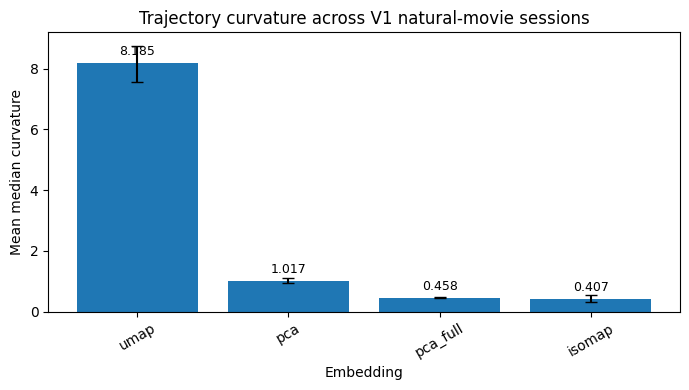

In [5]:
# ---------------------------------------------------------------------
# Notebook 14: clean multi-session geometry figure
# ---------------------------------------------------------------------

import matplotlib.pyplot as plt

plot_metric = "curvature_median"

plot_df = geometry_multisession_summary[
    geometry_multisession_summary["metric"] == plot_metric
].copy()

if plot_df.empty:
    raise RuntimeError(f"No rows found for plot metric: {plot_metric}")

plot_df = plot_df.sort_values("mean", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7, 4))

yerr = np.vstack([
    plot_df["mean"] - plot_df["ci_low"],
    plot_df["ci_high"] - plot_df["mean"],
])

ax.bar(
    plot_df["embedding"],
    plot_df["mean"],
    yerr=yerr,
    capsize=4,
)

ax.set_xlabel("Embedding")
ax.set_ylabel("Mean median curvature")
ax.set_title("Trajectory curvature across V1 natural-movie sessions")
ax.tick_params(axis="x", rotation=30)

for i, row in plot_df.iterrows():
    ax.text(
        i,
        row["mean"] + 0.02 * plot_df["mean"].max(),
        f"{row['mean']:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

fig.tight_layout()

save_figure(
    fig,
    paths.publication_figures_dir / "14_multisession_curvature_by_embedding.png",
)

plt.show()

## Merge session metadata and enforce publication gates

In [6]:
# ---------------------------------------------------------------------
# Notebook 14: add session metadata and geometry claim gates
# ---------------------------------------------------------------------

from pathlib import Path
import numpy as np
import pandas as pd

# Use the geometry table produced above.
geom_path = paths.publication_tables_dir / "14_geometry_with_session_metadata.csv"

if geom_path.exists():
    geom = pd.read_csv(geom_path)
elif "geom" in globals() and not geom.empty:
    geom = geom.copy()
else:
    raise FileNotFoundError(
        "No geometry table found. Run the geometry reconstruction cell first."
    )

geom["session_id"] = geom["session_id"].astype(str)

# ---------------------------------------------------------------------
# Add cohort/session metadata
# ---------------------------------------------------------------------

cohort_candidates = [
    paths.publication_tables_dir / "11_publication_candidate_cohort.csv",
    paths.tables_dir / "publication_upgrade_v2" / "11_publication_candidate_cohort.csv",
    paths.tables_dir / "publication_upgrade" / "11_publication_candidate_cohort.csv",
]

cohort = pd.DataFrame()

for cohort_path in cohort_candidates:
    if cohort_path.exists() and cohort_path.stat().st_size > 0:
        try:
            cohort = pd.read_csv(cohort_path)
            print("Using cohort metadata:", cohort_path)
            break
        except Exception as exc:
            print("Could not read cohort metadata:", cohort_path, repr(exc))

if not cohort.empty and "session_id" in cohort.columns:
    cohort = cohort.copy()
    cohort["session_id"] = (
        pd.to_numeric(cohort["session_id"], errors="coerce")
        .astype("Int64")
        .astype(str)
    )

    # Avoid duplicate columns if rerunning.
    overlap = [
        c for c in cohort.columns
        if c in geom.columns and c != "session_id"
    ]

    cohort_for_merge = cohort.drop(columns=overlap, errors="ignore")

    geom_meta = geom.merge(
        cohort_for_merge,
        on="session_id",
        how="left",
    )
else:
    print("No usable cohort metadata found. Proceeding with geometry table only.")
    geom_meta = geom.copy()

# ---------------------------------------------------------------------
# Add cell counts from tensor files
# ---------------------------------------------------------------------

cell_rows = []

try:
    from v1_manifold.preprocessing import load_trial_tensor_h5

    for session_id in geom_meta["session_id"].astype(str).unique():
        match = asset_index[
            asset_index["session_id"].astype(str) == str(session_id)
        ]

        if match.empty or "tensor_file" not in match.columns:
            continue

        tensor_file = match["tensor_file"].iloc[0]

        if pd.isna(tensor_file):
            continue

        tensor_path = Path(tensor_file)

        if tensor_path.exists():
            _, R = load_trial_tensor_h5(tensor_path)
            cell_rows.append({
                "session_id": str(session_id),
                "n_cells": int(R.shape[1]),
            })

except Exception as exc:
    print("Could not add cell counts:", repr(exc))

if cell_rows:
    cell_counts = pd.DataFrame(cell_rows).drop_duplicates("session_id")

    if "n_cells" in geom_meta.columns:
        geom_meta = geom_meta.drop(columns=["n_cells"])

    geom_meta = geom_meta.merge(
        cell_counts,
        on="session_id",
        how="left",
    )

save_table(
    geom_meta,
    paths.publication_tables_dir / "14_geometry_with_session_metadata.csv",
)

display(geom_meta.head(20))

# ---------------------------------------------------------------------
# Claim gates
# ---------------------------------------------------------------------

n_sessions = (
    geom_meta["session_id"].nunique()
    if not geom_meta.empty
    else 0
)

n_layers = (
    geom_meta["putative_layer"].dropna().nunique()
    if "putative_layer" in geom_meta.columns
    else 0
)

n_cre = (
    geom_meta["cre_line"].dropna().nunique()
    if "cre_line" in geom_meta.columns
    else 0
)

n_embeddings = (
    geom_meta["embedding"].dropna().nunique()
    if "embedding" in geom_meta.columns
    else 0
)

n_sessions_with_cells = (
    geom_meta.loc[geom_meta["n_cells"].notna(), "session_id"].nunique()
    if "n_cells" in geom_meta.columns
    else 0
)

gate_rows = [
    {
        "gate": "multi_session_geometry",
        "status": "pass" if n_sessions >= 3 else "fail",
        "value": n_sessions,
        "criterion": ">=3 fully embedded sessions",
        "interpretation": "Allows cautious multi-session geometry summaries.",
    },
    {
        "gate": "common_embedding_geometry",
        "status": "pass" if n_embeddings >= 4 else "fail",
        "value": n_embeddings,
        "criterion": ">=4 common embeddings reconstructed",
        "interpretation": "Allows comparison across PCA, PCA-full, UMAP, and ISOMAP.",
    },
    {
        "gate": "cell_count_available",
        "status": "pass" if n_sessions_with_cells >= 3 else "fail",
        "value": n_sessions_with_cells,
        "criterion": "cell counts available for >=3 sessions",
        "interpretation": "Allows cell-count-aware reporting and controls.",
    },
    {
        "gate": "multi_layer_geometry",
        "status": "pass" if n_layers >= 3 else "fail",
        "value": n_layers,
        "criterion": ">=3 represented layers",
        "interpretation": "Do not claim layer-specific geometry unless this passes.",
    },
    {
        "gate": "multi_cre_geometry",
        "status": "pass" if n_cre >= 2 else "fail",
        "value": n_cre,
        "criterion": ">=2 Cre lines",
        "interpretation": "Do not claim Cre-line-specific geometry unless this passes.",
    },
]

geometry_gates = pd.DataFrame(gate_rows)

save_table(
    geometry_gates,
    paths.publication_tables_dir / "14_geometry_claim_gates.csv",
)

display(geometry_gates)

Using cohort metadata: C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies\reports\tables\publication_upgrade_v2\11_publication_candidate_cohort.csv


,session_id,embedding,n_frames,embedding_dim,speed_median,speed_p99,speed_max,curvature_median,curvature_p99,curvature_max,...,acquisition_age_days,experiment_container_id,session_type,donor_name,specimen_name,fail_eye_tracking,putative_layer,source_table,is_preferred_cre_line,n_cells
0,500855614,pca,900,3,1.005158,2.503851,4.239799,1.107981,33.166636,191.321576,...,94,511507650,three_session_C,222424,Cux2-CreERT2;Camk2a-tTA;Ai93-222424,True,L2/3,allen_v1_natural_movie_experiments.csv,True,163
1,500855614,pca_full,900,20,2.677863,4.246316,5.324176,0.480364,1.543484,2.586151,...,94,511507650,three_session_C,222424,Cux2-CreERT2;Camk2a-tTA;Ai93-222424,True,L2/3,allen_v1_natural_movie_experiments.csv,True,163
2,500855614,umap,900,3,0.082220,0.752321,15.982136,8.756395,1795.714967,13350.645629,...,94,511507650,three_session_C,222424,Cux2-CreERT2;Camk2a-tTA;Ai93-222424,True,L2/3,allen_v1_natural_movie_experiments.csv,True,163
3,500855614,isomap,900,3,1.200051,5.479009,8.527684,0.533106,136.010347,5195.263502,...,94,511507650,three_session_C,222424,Cux2-CreERT2;Camk2a-tTA;Ai93-222424,True,L2/3,allen_v1_natural_movie_experiments.csv,True,163
4,500964514,pca,900,3,1.121127,3.401901,6.496040,0.999325,26.892121,72.917495,...,97,511509529,three_session_B,222420,Cux2-CreERT2;Camk2a-tTA;Ai93-222420,True,L2/3,allen_v1_natural_movie_experiments.csv,True,214
5,500964514,pca_full,900,20,3.003222,4.910268,7.692817,0.448225,1.387568,2.730126,...,97,511509529,three_session_B,222420,Cux2-CreERT2;Camk2a-tTA;Ai93-222420,True,L2/3,allen_v1_natural_movie_experiments.csv,True,214
6,500964514,umap,900,3,0.080179,0.437021,6.416957,8.253039,1212.330990,23931.042516,...,97,511509529,three_session_B,222420,Cux2-CreERT2;Camk2a-tTA;Ai93-222420,True,L2/3,allen_v1_natural_movie_experiments.csv,True,214
7,500964514,isomap,900,3,3.832981,12.892728,20.741220,0.366092,27.438089,116.334468,...,97,511509529,three_session_B,222420,Cux2-CreERT2;Camk2a-tTA;Ai93-222420,True,L2/3,allen_v1_natural_movie_experiments.csv,True,214
8,501271265,pca,900,3,1.186652,3.226026,5.884359,0.943038,31.000895,377.745891,...,100,511509529,three_session_A,222420,Cux2-CreERT2;Camk2a-tTA;Ai93-222420,True,L2/3,allen_v1_natural_movie_experiments.csv,True,215
9,501271265,pca_full,900,20,2.878449,4.561172,6.913401,0.446380,1.542350,1.936209,...,100,511509529,three_session_A,222420,Cux2-CreERT2;Camk2a-tTA;Ai93-222420,True,L2/3,allen_v1_natural_movie_experiments.csv,True,215


,gate,status,value,criterion,interpretation
0,multi_session_geometry,pass,3,>=3 fully embedded sessions,Allows cautious multi-session geometry summaries.
1,common_embedding_geometry,pass,4,>=4 common embeddings reconstructed,"Allows comparison across PCA, PCA-full, UMAP, ..."
2,cell_count_available,pass,3,cell counts available for >=3 sessions,Allows cell-count-aware reporting and controls.
3,multi_layer_geometry,fail,1,>=3 represented layers,Do not claim layer-specific geometry unless th...
4,multi_cre_geometry,fail,1,>=2 Cre lines,Do not claim Cre-line-specific geometry unless...


## Bootstrap uncertainty by embedding, layer, and Cre line

In [7]:
# ---------------------------------------------------------------------
# Notebook 14: valid geometry bootstrap CIs by embedding only
# ---------------------------------------------------------------------

from v1_manifold_publication.stats import bootstrap_ci
import numpy as np
import pandas as pd

# Use only columns that summarize geometry distributions.
value_cols = [
    c for c in geom_meta.columns
    if c.endswith("_median") or c.endswith("_p99") or c.endswith("_max")
]

summary_rows = []

if geom_meta.empty:
    raise RuntimeError("geom_meta is empty. Run the geometry metadata/claim-gate cell first.")

for col in value_cols:
    for embedding, sub in geom_meta.groupby("embedding", dropna=False):
        values = pd.to_numeric(sub[col], errors="coerce").dropna().to_numpy()

        if len(values) == 0:
            continue

        ci = bootstrap_ci(
            values,
            n_bootstrap=int(cfg["models"].get("n_bootstrap", 1000)),
            rng=cfg["project"]["random_seed"],
        )

        summary_rows.append({
            "embedding": embedding,
            "metric": col,
            "n_sessions": int(sub["session_id"].nunique()),
            "mean": float(np.mean(values)),
            "median": float(np.median(values)),
            "std": float(np.std(values, ddof=1)) if len(values) > 1 else 0.0,
            "ci_low": ci["ci_low"],
            "ci_high": ci["ci_high"],
            "claim_scope": "multi_session_embedding_geometry",
            "claim_status": "supported" if sub["session_id"].nunique() >= 3 else "exploratory",
        })

geom_ci = pd.DataFrame(summary_rows)

save_table(
    geom_ci,
    paths.publication_tables_dir / "14_geometry_bootstrap_ci_by_embedding.csv",
)

display(
    geom_ci
    .sort_values(["metric", "mean"], ascending=[True, False])
    .head(40)
)

,embedding,metric,n_sessions,mean,median,std,ci_low,ci_high,claim_scope,claim_status
23,umap,curvature_max,3,18903.736615,19429.521700,5309.758661,13350.645629,23931.042516,multi_session_embedding_geometry,supported
20,isomap,curvature_max,3,1864.210022,281.032095,2885.952060,116.334468,5195.263502,multi_session_embedding_geometry,supported
21,pca,curvature_max,3,213.994987,191.321576,153.673844,72.917495,377.745891,multi_session_embedding_geometry,supported
22,pca_full,curvature_max,3,2.417495,2.586151,0.422977,1.936209,2.730126,multi_session_embedding_geometry,supported
15,umap,curvature_median,3,8.185327,8.253039,0.607760,7.546547,8.756395,multi_session_embedding_geometry,supported
13,pca,curvature_median,3,1.016781,0.999325,0.083846,0.943038,1.107981,multi_session_embedding_geometry,supported
14,pca_full,curvature_median,3,0.458323,0.448225,0.019110,0.446380,0.480364,multi_session_embedding_geometry,supported
12,isomap,curvature_median,3,0.407156,0.366092,0.111255,0.322271,0.533106,multi_session_embedding_geometry,supported
19,umap,curvature_p99,3,1551.896487,1647.643504,303.248800,1212.330990,1795.714967,multi_session_embedding_geometry,supported
16,isomap,curvature_p99,3,58.842627,27.438089,67.213729,13.079446,136.010347,multi_session_embedding_geometry,supported


In [8]:
# ---------------------------------------------------------------------
# Notebook 14: blocked biological subgroup claims
# ---------------------------------------------------------------------

blocked_rows = []

n_layers = (
    geom_meta["putative_layer"].dropna().nunique()
    if "putative_layer" in geom_meta.columns
    else 0
)

n_cre = (
    geom_meta["cre_line"].dropna().nunique()
    if "cre_line" in geom_meta.columns
    else 0
)

blocked_rows.append({
    "claim": "layer_specific_geometry",
    "status": "blocked",
    "reason": f"Only {n_layers} putative layer(s) represented.",
    "required_for_claim": "At least 3 represented layers with enough sessions per layer.",
})

blocked_rows.append({
    "claim": "cre_line_specific_geometry",
    "status": "blocked",
    "reason": f"Only {n_cre} Cre line(s) represented.",
    "required_for_claim": "At least 2 Cre lines with enough sessions per Cre line.",
})

blocked_geometry_claims = pd.DataFrame(blocked_rows)

save_table(
    blocked_geometry_claims,
    paths.publication_tables_dir / "14_blocked_layer_cre_geometry_claims.csv",
)

display(blocked_geometry_claims)

,claim,status,reason,required_for_claim
0,layer_specific_geometry,blocked,Only 1 putative layer(s) represented.,At least 3 represented layers with enough sess...
1,cre_line_specific_geometry,blocked,Only 1 Cre line(s) represented.,At least 2 Cre lines with enough sessions per ...


## Cell-count-matched PCA geometry across sessions

In [10]:
# ---------------------------------------------------------------------
# Notebook 14: manual cell-count-matched PCA geometry control
# ---------------------------------------------------------------------
# This replaces the failed cell_count_matched_metric_table(...) call.
# It samples the same number of cells from each session and computes
# PCA participation ratio for each subsample.
# ---------------------------------------------------------------------

import numpy as np
import pandas as pd

from v1_manifold_publication.stats import bootstrap_ci

# ---------------------------------------------------------------------
# Check that population_by_session exists from the previous successful load
# ---------------------------------------------------------------------

if "population_by_session" not in globals() or not population_by_session:
    raise RuntimeError(
        "population_by_session is missing. Re-run the tensor-loading part of the previous cell first."
    )

# ---------------------------------------------------------------------
# Settings
# ---------------------------------------------------------------------

available_cell_counts = {
    str(session_id): int(R.shape[1])
    for session_id, R in population_by_session.items()
}

min_available = min(available_cell_counts.values())

requested = cfg.get("models", {}).get("matched_cell_count", None)

matched_cell_count = int(
    min(requested or min_available, min_available)
)

n_subsamples = int(
    cfg.get("models", {}).get("n_cell_subsamples", 100)
)

rng = np.random.default_rng(cfg["project"]["random_seed"])

print("Available cell counts:", available_cell_counts)
print("Matched cell count:", matched_cell_count)
print("Number of subsamples:", n_subsamples)

# ---------------------------------------------------------------------
# Metric
# ---------------------------------------------------------------------

def pca_geometry_metric(X):
    """
    Compute PCA participation ratio from a frame-by-cell matrix.

    X shape: [n_frames, n_cells]
    """
    X = np.asarray(X, dtype=float)

    if X.ndim != 2:
        raise ValueError(f"Expected 2D matrix, got shape {X.shape}")

    X = X - X.mean(axis=0, keepdims=True)

    s = np.linalg.svd(X, full_matrices=False, compute_uv=False)

    lambdas = s**2 / max(X.shape[0] - 1, 1)

    participation_ratio = (
        (lambdas.sum() ** 2)
        / (np.sum(lambdas**2) + 1e-12)
    )

    return {
        "pca_participation_ratio": float(participation_ratio),
        "n_frames": int(X.shape[0]),
    }

# ---------------------------------------------------------------------
# Manual matched-cell subsampling
# ---------------------------------------------------------------------

matched_rows = []

for session_id, R in population_by_session.items():
    session_id = str(session_id)
    R = np.asarray(R, dtype=float)

    n_available_cells = R.shape[1]

    if n_available_cells < matched_cell_count:
        print(
            f"Skipping session {session_id}: only {n_available_cells} cells, "
            f"need {matched_cell_count}."
        )
        continue

    print(f"Sampling session {session_id}: R={R.shape}")

    for subsample in range(n_subsamples):
        cell_indices = rng.choice(
            n_available_cells,
            size=matched_cell_count,
            replace=False,
        )

        X_sub = R[:, cell_indices]

        metrics = pca_geometry_metric(X_sub)

        matched_rows.append({
            "session_id": session_id,
            "subsample": subsample,
            "matched_cell_count": matched_cell_count,
            "available_cell_count": n_available_cells,
            "cell_indices": " ".join(map(str, cell_indices.tolist())),
            **metrics,
        })

matched_geometry = pd.DataFrame(matched_rows)

# ---------------------------------------------------------------------
# Add metadata
# ---------------------------------------------------------------------

if not matched_geometry.empty and "geom_meta" in globals() and not geom_meta.empty:
    metadata_cols = [
        c for c in [
            "session_id",
            "putative_layer",
            "cre_line",
            "imaging_depth",
            "session_type",
            "donor_name",
        ]
        if c in geom_meta.columns
    ]

    if "session_id" in metadata_cols:
        meta_unique = (
            geom_meta[metadata_cols]
            .copy()
            .drop_duplicates("session_id")
        )

        meta_unique["session_id"] = meta_unique["session_id"].astype(str)
        matched_geometry["session_id"] = matched_geometry["session_id"].astype(str)

        matched_geometry = matched_geometry.merge(
            meta_unique,
            on="session_id",
            how="left",
        )

matched_geometry["n_subsamples"] = n_subsamples
matched_geometry["claim_scope"] = "cell_count_matched_session_control"

save_table(
    matched_geometry,
    paths.publication_tables_dir / "14_cell_count_matched_pca_geometry.csv",
)

display(matched_geometry.head(20))

# ---------------------------------------------------------------------
# Session-level bootstrap summaries
# ---------------------------------------------------------------------

session_summary_rows = []

for session_id, sub in matched_geometry.groupby("session_id", dropna=False):
    values = (
        pd.to_numeric(sub["pca_participation_ratio"], errors="coerce")
        .dropna()
        .to_numpy()
    )

    if len(values) == 0:
        continue

    ci = bootstrap_ci(
        values,
        n_bootstrap=int(cfg["models"].get("n_bootstrap", 1000)),
        rng=cfg["project"]["random_seed"],
    )

    session_summary_rows.append({
        "session_id": str(session_id),
        "n_subsamples": int(len(values)),
        "matched_cell_count": matched_cell_count,
        "mean_pca_participation_ratio": float(np.mean(values)),
        "median_pca_participation_ratio": float(np.median(values)),
        "std_pca_participation_ratio": float(np.std(values, ddof=1)) if len(values) > 1 else 0.0,
        "ci_low": ci["ci_low"],
        "ci_high": ci["ci_high"],
        "claim_scope": "within_session_cell_count_matched_stability",
    })

matched_session_summary = pd.DataFrame(session_summary_rows)

save_table(
    matched_session_summary,
    paths.publication_tables_dir / "14_cell_count_matched_pca_geometry_session_summary.csv",
)

display(matched_session_summary)

# ---------------------------------------------------------------------
# Across-session summary
# ---------------------------------------------------------------------

session_means = (
    matched_session_summary["mean_pca_participation_ratio"]
    .dropna()
    .to_numpy()
)

if len(session_means):
    across_ci = bootstrap_ci(
        session_means,
        n_bootstrap=int(cfg["models"].get("n_bootstrap", 1000)),
        rng=cfg["project"]["random_seed"],
    )

    matched_across_session_summary = pd.DataFrame([{
        "n_sessions": int(len(session_means)),
        "matched_cell_count": matched_cell_count,
        "mean_session_pca_participation_ratio": float(np.mean(session_means)),
        "median_session_pca_participation_ratio": float(np.median(session_means)),
        "std_session_pca_participation_ratio": float(np.std(session_means, ddof=1)) if len(session_means) > 1 else 0.0,
        "ci_low": across_ci["ci_low"],
        "ci_high": across_ci["ci_high"],
        "claim_scope": "cell_count_matched_across_session_summary",
    }])
else:
    matched_across_session_summary = pd.DataFrame()

save_table(
    matched_across_session_summary,
    paths.publication_tables_dir / "14_cell_count_matched_pca_geometry_across_session_summary.csv",
)

display(matched_across_session_summary)

print("Saved:")
print(paths.publication_tables_dir / "14_cell_count_matched_pca_geometry.csv")
print(paths.publication_tables_dir / "14_cell_count_matched_pca_geometry_session_summary.csv")
print(paths.publication_tables_dir / "14_cell_count_matched_pca_geometry_across_session_summary.csv")

Available cell counts: {'500855614': 163, '500964514': 214, '501271265': 215}
Matched cell count: 50
Number of subsamples: 100
Sampling session 500855614: R=(900, 163)
Sampling session 500964514: R=(900, 214)
Sampling session 501271265: R=(900, 215)


,session_id,subsample,matched_cell_count,available_cell_count,cell_indices,pca_participation_ratio,n_frames,putative_layer,cre_line,imaging_depth,session_type,donor_name,n_subsamples,claim_scope
0,500855614,0,50,163,56 66 59 10 162 158 138 109 42 71 55 161 117 1...,4.617342,900,L2/3,Cux2-CreERT2,175,three_session_C,222424,100,cell_count_matched_session_control
1,500855614,1,50,163,147 58 95 136 90 64 45 53 157 59 98 0 79 119 1...,13.181154,900,L2/3,Cux2-CreERT2,175,three_session_C,222424,100,cell_count_matched_session_control
2,500855614,2,50,163,101 28 59 122 25 119 151 57 154 83 91 156 125 ...,10.031352,900,L2/3,Cux2-CreERT2,175,three_session_C,222424,100,cell_count_matched_session_control
3,500855614,3,50,163,14 161 45 137 48 87 1 39 128 43 13 32 124 147 ...,9.755745,900,L2/3,Cux2-CreERT2,175,three_session_C,222424,100,cell_count_matched_session_control
4,500855614,4,50,163,127 2 110 61 120 59 60 38 108 62 32 81 87 123 ...,9.810113,900,L2/3,Cux2-CreERT2,175,three_session_C,222424,100,cell_count_matched_session_control
5,500855614,5,50,163,135 31 127 108 56 105 112 70 9 136 50 88 49 66...,9.166628,900,L2/3,Cux2-CreERT2,175,three_session_C,222424,100,cell_count_matched_session_control
6,500855614,6,50,163,36 16 76 87 110 148 74 28 94 51 103 124 138 15...,10.354448,900,L2/3,Cux2-CreERT2,175,three_session_C,222424,100,cell_count_matched_session_control
7,500855614,7,50,163,70 145 106 104 29 143 102 75 96 17 61 68 72 16...,7.644259,900,L2/3,Cux2-CreERT2,175,three_session_C,222424,100,cell_count_matched_session_control
8,500855614,8,50,163,130 153 95 138 99 121 54 37 69 137 36 46 14 10...,11.649985,900,L2/3,Cux2-CreERT2,175,three_session_C,222424,100,cell_count_matched_session_control
9,500855614,9,50,163,150 5 74 140 12 141 64 161 45 151 39 112 82 48...,9.596520,900,L2/3,Cux2-CreERT2,175,three_session_C,222424,100,cell_count_matched_session_control


,session_id,n_subsamples,matched_cell_count,mean_pca_participation_ratio,median_pca_participation_ratio,std_pca_participation_ratio,ci_low,ci_high,claim_scope
0,500855614,100,50,9.175682,9.174822,2.263825,8.728125,9.628336,within_session_cell_count_matched_stability
1,500964514,100,50,8.491070,8.238145,1.817364,8.131217,8.858562,within_session_cell_count_matched_stability
2,501271265,100,50,9.006799,8.860082,1.834672,8.655115,9.382382,within_session_cell_count_matched_stability


,n_sessions,matched_cell_count,mean_session_pca_participation_ratio,median_session_pca_participation_ratio,std_session_pca_participation_ratio,ci_low,ci_high,claim_scope
0,3,50,8.891184,9.006799,0.356649,8.49107,9.175682,cell_count_matched_across_session_summary


Saved:
C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies\reports\tables\publication_upgrade_v3_multisession\14_cell_count_matched_pca_geometry.csv
C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies\reports\tables\publication_upgrade_v3_multisession\14_cell_count_matched_pca_geometry_session_summary.csv
C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies\reports\tables\publication_upgrade_v3_multisession\14_cell_count_matched_pca_geometry_across_session_summary.csv


## Layer/Cre-line comparison table and figures

,factor,metric,status,reason,n_groups,n_sessions,count,mean,median,std
0,putative_layer,speed_median,blocked,putative_layer comparison blocked by claim gates.,1,3,NaN,NaN,NaN,NaN
1,cre_line,speed_median,blocked,cre_line comparison blocked by claim gates.,1,3,NaN,NaN,NaN,NaN
2,putative_layer,curvature_median,blocked,putative_layer comparison blocked by claim gates.,1,3,NaN,NaN,NaN,NaN
3,cre_line,curvature_median,blocked,cre_line comparison blocked by claim gates.,1,3,NaN,NaN,NaN,NaN
4,putative_layer,tangling_median,blocked,putative_layer comparison blocked by claim gates.,1,3,NaN,NaN,NaN,NaN
5,cre_line,tangling_median,blocked,cre_line comparison blocked by claim gates.,1,3,NaN,NaN,NaN,NaN


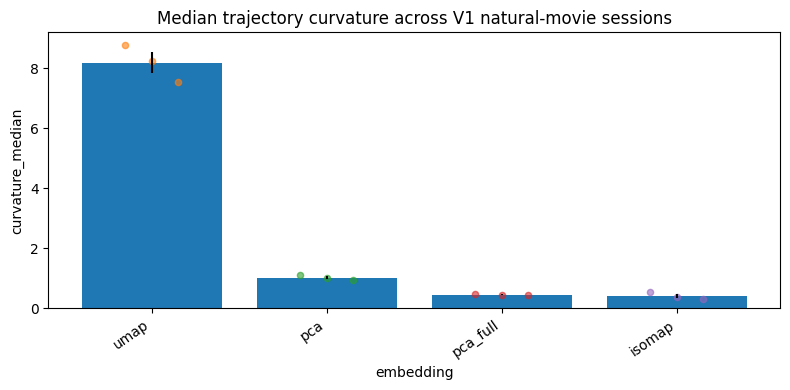

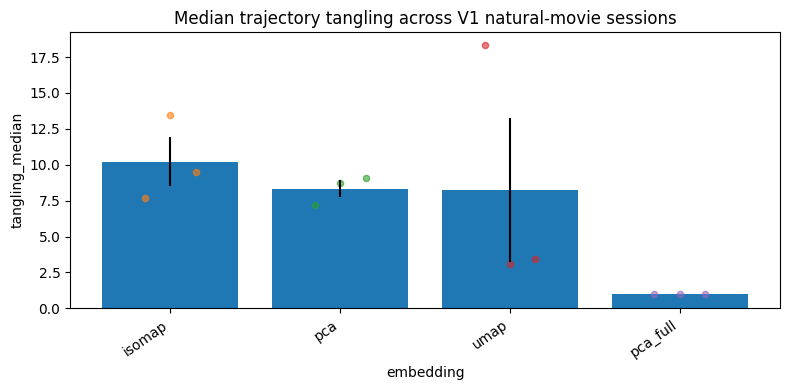

In [12]:
# ---------------------------------------------------------------------
# Notebook 14: geometry statistics and publication figures
# ---------------------------------------------------------------------
# Layer/Cre statistics are blocked because only one layer and one Cre line
# are represented. We still generate valid embedding-level geometry figures.
# ---------------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from v1_manifold_publication.plotting import bar_with_points, savefig

# ---------------------------------------------------------------------
# Block layer/Cre inferential statistics unless gates pass
# ---------------------------------------------------------------------

geometry_gates_path = paths.publication_tables_dir / "14_geometry_claim_gates.csv"

if geometry_gates_path.exists():
    geometry_gates = pd.read_csv(geometry_gates_path)
else:
    geometry_gates = pd.DataFrame()


def gate_passed(gate_name):
    if geometry_gates.empty:
        return False

    rows = geometry_gates[geometry_gates["gate"] == gate_name]

    if rows.empty:
        return False

    return str(rows["status"].iloc[0]).lower() == "pass"


layer_gate = gate_passed("multi_layer_geometry")
cre_gate = gate_passed("multi_cre_geometry")

stats_rows = []

if geom_meta.empty:
    print("geom_meta is empty. Run the metadata/claim-gate cell first.")

else:
    geometry_metrics = [
        c for c in geom_meta.columns
        if c.endswith("_median")
    ]

    for metric in geometry_metrics:
        for factor, gate_ok in [
            ("putative_layer", layer_gate),
            ("cre_line", cre_gate),
        ]:
            if factor not in geom_meta.columns:
                stats_rows.append({
                    "factor": factor,
                    "metric": metric,
                    "status": "blocked",
                    "reason": f"{factor} column not available.",
                    "n_groups": 0,
                    "n_sessions": int(geom_meta["session_id"].nunique()),
                })
                continue

            n_groups = int(geom_meta[factor].dropna().nunique())
            n_sessions = int(geom_meta["session_id"].nunique())

            if not gate_ok:
                stats_rows.append({
                    "factor": factor,
                    "metric": metric,
                    "status": "blocked",
                    "reason": f"{factor} comparison blocked by claim gates.",
                    "n_groups": n_groups,
                    "n_sessions": n_sessions,
                    "count": np.nan,
                    "mean": np.nan,
                    "median": np.nan,
                    "std": np.nan,
                })
                continue

            groups = geom_meta.dropna(subset=[factor, metric]).groupby(factor)

            if groups.ngroups < 2:
                stats_rows.append({
                    "factor": factor,
                    "metric": metric,
                    "status": "blocked",
                    "reason": "Fewer than two groups available.",
                    "n_groups": int(groups.ngroups),
                    "n_sessions": n_sessions,
                    "count": np.nan,
                    "mean": np.nan,
                    "median": np.nan,
                    "std": np.nan,
                })
                continue

            summary = (
                groups[metric]
                .agg(["count", "mean", "median", "std"])
                .reset_index()
            )

            for _, row in summary.iterrows():
                stats_rows.append({
                    "factor": factor,
                    "factor_level": row[factor],
                    "metric": metric,
                    "status": "computed",
                    "reason": "Claim gate passed.",
                    "n_groups": int(groups.ngroups),
                    "n_sessions": n_sessions,
                    "count": int(row["count"]),
                    "mean": float(row["mean"]),
                    "median": float(row["median"]),
                    "std": float(row["std"]) if pd.notna(row["std"]) else np.nan,
                })

layer_or_cre_stats = pd.DataFrame(stats_rows)

save_table(
    layer_or_cre_stats,
    paths.publication_tables_dir / "14_layer_or_cre_geometry_statistics.csv",
)

display(layer_or_cre_stats.head(30))

# ---------------------------------------------------------------------
# Valid embedding-level figures
# ---------------------------------------------------------------------

if not geom_meta.empty and "curvature_median" in geom_meta.columns:
    fig = bar_with_points(
        geom_meta,
        x="embedding",
        y="curvature_median",
        title="Median trajectory curvature across V1 natural-movie sessions",
    )

    savefig(
        fig,
        paths.publication_figures_dir / "14_median_curvature_by_embedding.png",
    )

    plt.show()

if not geom_meta.empty and "tangling_median" in geom_meta.columns:
    fig = bar_with_points(
        geom_meta,
        x="embedding",
        y="tangling_median",
        title="Median trajectory tangling across V1 natural-movie sessions",
    )

    savefig(
        fig,
        paths.publication_figures_dir / "14_median_tangling_by_embedding.png",
    )

    plt.show()

In [13]:
# ---------------------------------------------------------------------
# Notebook 14 completion checkpoint
# ---------------------------------------------------------------------

expected_outputs = [
    "publication_reconstructed_embedding_geometry.csv",
    "14_geometry_with_session_metadata.csv",
    "14_geometry_reconstruction_status.csv",
    "14_geometry_multisession_bootstrap_summary.csv",
    "14_geometry_bootstrap_ci_by_embedding.csv",
    "14_geometry_claim_gates.csv",
    "14_blocked_layer_cre_geometry_claims.csv",
    "14_layer_or_cre_geometry_statistics.csv",
    "14_cell_count_matched_pca_geometry.csv",
    "14_cell_count_matched_pca_geometry_session_summary.csv",
    "14_cell_count_matched_pca_geometry_across_session_summary.csv",
]

rows = []

for name in expected_outputs:
    path = paths.publication_tables_dir / name
    rows.append({
        "file": name,
        "exists": path.exists(),
        "size_kb": round(path.stat().st_size / 1024, 2) if path.exists() else 0,
    })

notebook14_checkpoint = pd.DataFrame(rows)

save_table(
    notebook14_checkpoint,
    paths.publication_tables_dir / "14_notebook_completion_checkpoint.csv",
)

display(notebook14_checkpoint)

,file,exists,size_kb
0,publication_reconstructed_embedding_geometry.csv,True,2.39
1,14_geometry_with_session_metadata.csv,True,4.72
2,14_geometry_reconstruction_status.csv,True,0.44
3,14_geometry_multisession_bootstrap_summary.csv,True,4.10
4,14_geometry_bootstrap_ci_by_embedding.csv,True,5.64
5,14_geometry_claim_gates.csv,True,0.59
6,14_blocked_layer_cre_geometry_claims.csv,True,0.29
7,14_layer_or_cre_geometry_statistics.csv,True,0.60
8,14_cell_count_matched_pca_geometry.csv,True,87.75
9,14_cell_count_matched_pca_geometry_session_sum...,True,0.60
